In [10]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker
import seaborn as sns

# Global font: bold Times New Roman, larger size
plt.rcParams.update({
    'font.size': 22,
    'font.family': 'serif',
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'font.serif': ['Times New Roman']
})

plt.rcParams['figure.constrained_layout.use'] = True

# Load benchmark CSVs
csv_files = list(Path('../Benchmark/bench_results').glob('bench_*.csv'))
if not csv_files:
    raise FileNotFoundError("No benchmark CSV files found. Make sure you're running from the project root.")
frames = []
for fp in csv_files:
    df = pd.read_csv(fp)
    df = df[~df['query'].str.startswith('preload_')]
    frames.append(df)
data = pd.concat(frames, ignore_index=True)
data['size'] = data['size'].astype(int)
# data[(data['baseline'] == 'vtab') & (data['size'] == 100000)]
data

,baseline,query,size,mean_ms,std_ms
0,preload,contactFull,1000,2.703962,0.064791
1,preload,contactProj,1000,1.559700,0.023107
2,preload,contactPred,1000,0.046363,0.009106
3,preload,photoFull,1000,2457.695875,106.554915
4,preload,photoProj,1000,2347.480450,37.660945
...,...,...,...,...,...
94,nopushdown,contactPred,1000,25.078613,0.738301
95,nopushdown,photoFull,1000,1384.063229,53.005583
96,nopushdown,photoProj,1000,1250.998883,45.606408
97,nopushdown,photoPred,1000,1217.461237,14.723236


In [11]:
def plot_group(queries, fig_slug=None):
    # Map new display titles to acceptable underlying query names (for backward compatibility)
    aliases = {
        'Contacts - Full': ['Contacts - Full', 'contactFull'],
        'Contacts - Projection': ['Contacts - Projection', 'contactProj'],
        'Contacts - Predicate': ['Contacts - Predicate', 'contactPred'],
        'Photos - Full': ['Photos - Full', 'photoFull'],
        'Photos - Projection': ['Photos - Projection', 'photoProj'],
        'Photos - Predicate': ['Photos - Predicate', 'photoPred'],
        'Photos - Order By / Limit': ['Photos - Order By / Limit', 'photoOrder'],
        'Location - Order By / Limit': ['Location - Order By / Limit', 'locOrder'],
    }

    baselines = data['baseline'].unique()
    # Map internal baseline keys to display labels
    baseline_label_map = {'preload': 'MT', 'nopushdown': 'VT', 'vtab': 'VTP'}

    # Colorblind-safe Okabe–Ito palette; VTP shares blue with escrow in overhead
    okabe_ito_colors = {
        'vtab': '#009E73',  # green (main)
        'preload': '#E69F00',  # orange
        'nopushdown': '#56B4E9',     # blue
    }

    n = len(queries)
    figsize = (24, 4) if n == 4 else (20, 4)

    fig, axes = plt.subplots(1, n, figsize=figsize, sharey=False)
    if n == 1:
        axes = [axes]

    baseline_colors = {b: okabe_ito_colors.get(b, '#666666') for b in baselines}

    for ax, display_name in zip(axes, queries):
        key_list = aliases.get(display_name, [display_name])
        is_loc_plot = display_name.startswith('Location')

        if is_loc_plot:
            # Bar plot at x=1, one bar per baseline
            B = len(baselines)
            width = 0.8 / max(B, 1)
            for j, baseline in enumerate(baselines):
                d = data[(data['query'].isin(key_list)) & (data['baseline'] == baseline)].sort_values('size')
                if d.empty:
                    continue
                # choose a single point (largest size available)
                d_point = d.loc[d['size'].idxmax()]
                mean = float(d_point['mean_ms'])
                sem = float(d_point['std_ms'])
                x = 1 + (j - (B - 1) / 2) * (width + 0.05)
                ax.bar(x, mean, width=width, color=baseline_colors[baseline], label=baseline_label_map.get(baseline, baseline), edgecolor='black')
                ax.errorbar(x, mean, yerr=sem, fmt='none', ecolor='black', capsize=5, linewidth=1)
            ax.set_xticks([1])
            ax.set_xticklabels(['1'])
            ax.set_yscale('log')
        else:
            # Line plot with SEM error bars
            for baseline in baselines:
                d = data[(data['query'].isin(key_list)) & (data['baseline'] == baseline)].sort_values('size')
                if d.empty:
                    continue
                sem = d['std_ms']
                ax.errorbar(x=d['size'], y=d['mean_ms'], yerr=sem, label=baseline_label_map.get(baseline, baseline),
                            marker='o', markersize=10, capsize=6, color=baseline_colors[baseline], lw=3)
            ax.set_xscale('log')
            ax.set_yscale('log')
            sizes_present = sorted(data[data['query'].isin(key_list)]['size'].unique())
            ax.set_xticks(sizes_present)
            ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())

        ax.set_title(display_name)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(axis='x', which='major')
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, fontsize=20)

    axes[0].set_ylabel('Runtime (ms)', fontweight='bold')
    fig.supxlabel('Data Size', y=-0.08, fontweight='bold')

    slug = fig_slug if fig_slug else 'bench_group'
    fig_name = f"figures/bench/{slug}.pdf"
    plt.savefig(fig_name, bbox_inches='tight')
    plt.show()
    plt.close()


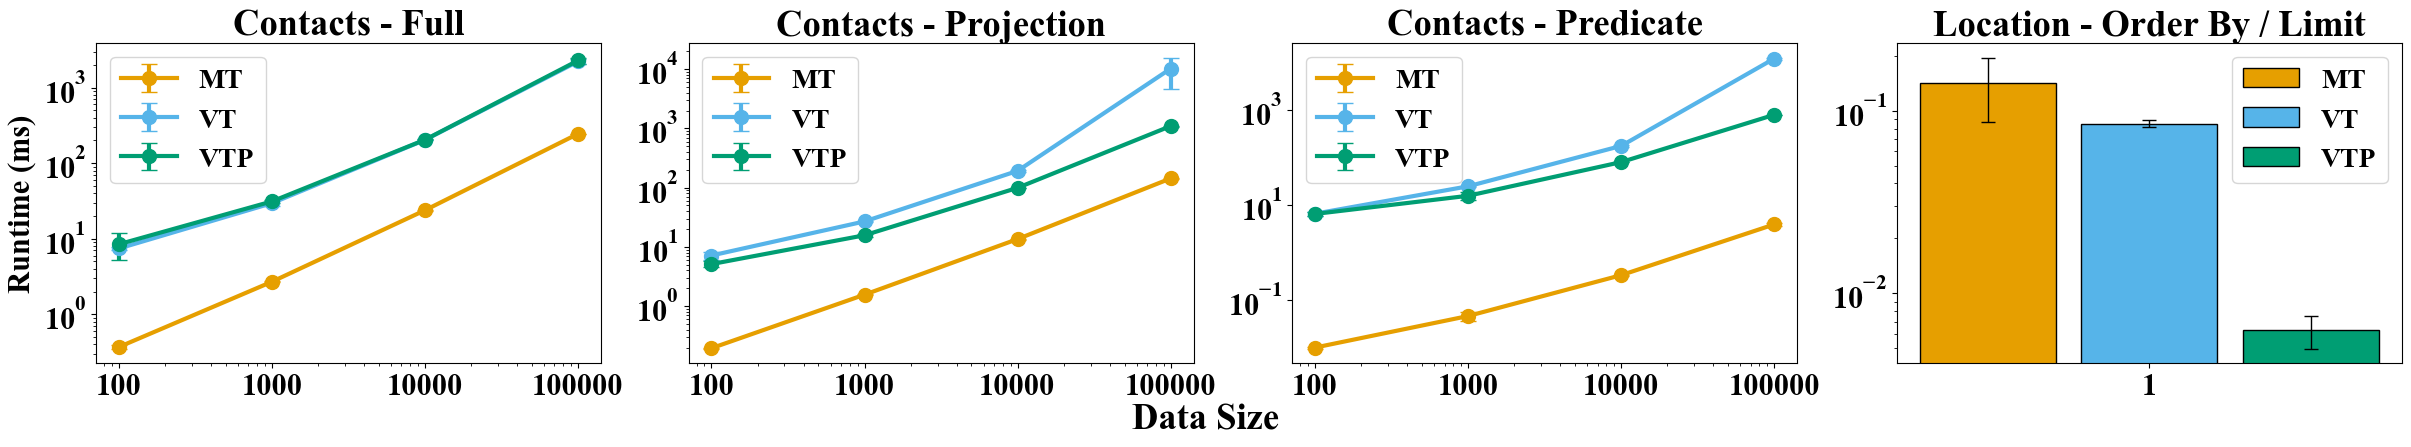

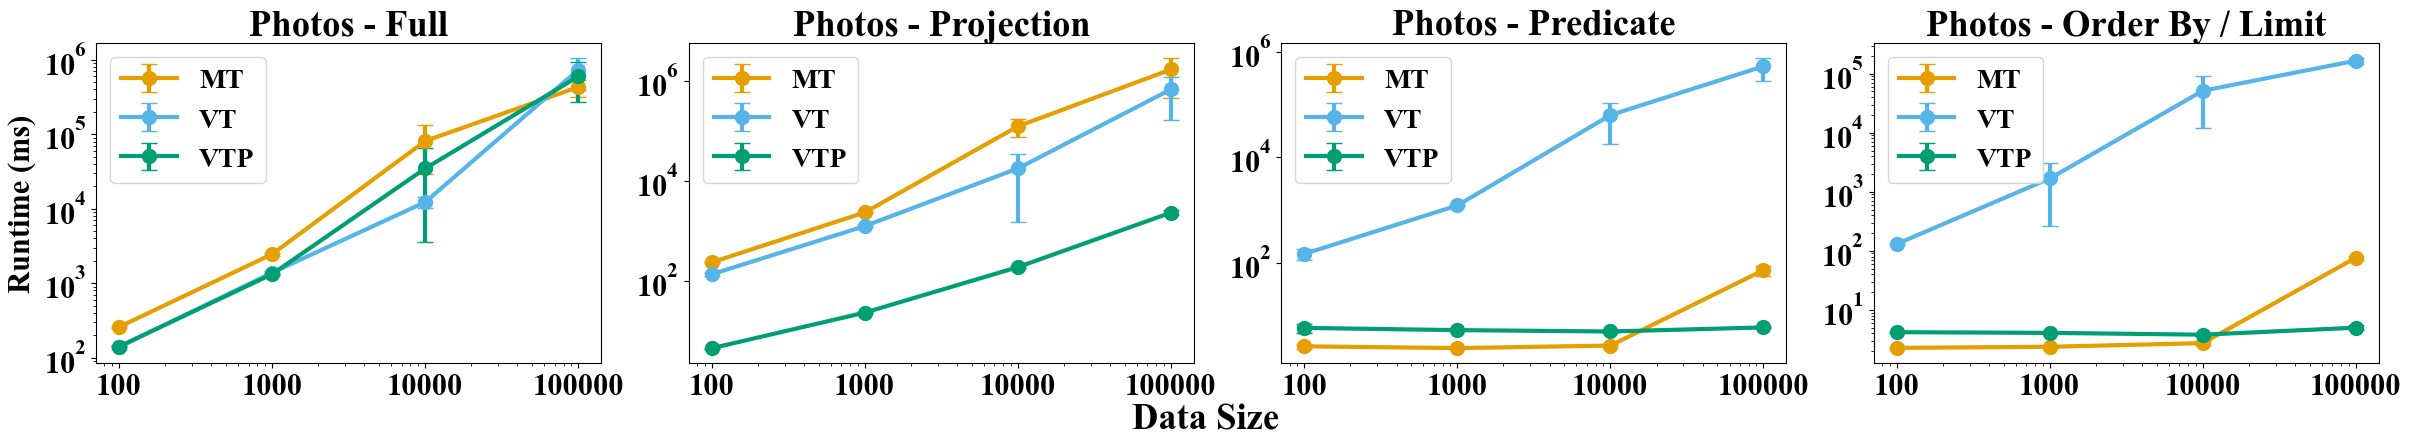

In [12]:
plot_group(['Contacts - Full', 'Contacts - Projection', 'Contacts - Predicate', 'Location - Order By / Limit'], fig_slug='contacts_and_location')
plot_group(['Photos - Full', 'Photos - Projection', 'Photos - Predicate', 'Photos - Order By / Limit'], fig_slug='photos')
